In [2]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
from sklearn.model_selection import train_test_split
from  sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import  RandomForestRegressor

In [5]:
from sklearn.metrics import (mean_absolute_error , 
mean_squared_error , r2_score)

In [6]:
df = pd.read_excel("../data/Pizza_Sales_Dataset.xlsx")

In [7]:
df.head()

,Date,Pizza_Name,Category,Pizza_Code,Price_USD,Sales,Unsold,Revenue,Rating
0,01 January 2022,Deluxe,Non-Veg,4,15,61,7,915,Average Seller
1,01 January 2022,Double Cheese,Veg,5,9,68,9,612,Average Seller
2,01 January 2022,Farmhouse,Veg,3,7,284,23,1988,Top Seller
3,02 January 2023,Deluxe,Non-Veg,4,15,133,9,1995,Top Seller
4,02 January 2023,Double Cheese,Veg,5,9,194,21,1746,Top Seller


In [8]:
df.shape

(61, 9)

In [9]:
# Can we predict the number of pizzas sold using information available about the pizza and sale?
target = "Sales"


In [10]:
# Create date features
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day
df["Day_Name"] = df["Date"].dt.day_name()

In [11]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_Week"] = df["Date"].dt.dayofweek

In [12]:
X = df[
    [
        "Pizza_Name" , 
        "Category",
        "Pizza_Code",
        "Price_USD",
        "Year",
        "Month",
        "Day" , 
        "Day_of_Week"
    ]
    ]

y = df["Sales"]

In [13]:
X.head()

,Pizza_Name,Category,Pizza_Code,Price_USD,Year,Month,Day,Day_of_Week
0,Deluxe,Non-Veg,4,15,2022,1,1,5
1,Double Cheese,Veg,5,9,2022,1,1,5
2,Farmhouse,Veg,3,7,2022,1,1,5
3,Deluxe,Non-Veg,4,15,2023,1,2,0
4,Double Cheese,Veg,5,9,2023,1,2,0


In [14]:
y.head()

0     61
1     68
2    284
3    133
4    194
Name: Sales, dtype: int64

In [36]:
X_train , X_test , y_train , y_test = train_test_split(
    X , 
    y , 
    test_size = 0.2,
    random_state = 42
)

In [37]:
print("Training_Date" , X_train.shape)
print("Testing_Data " , X_test.shape)

Training_Date (48, 8)
Testing_Data  (13, 8)


In [38]:
#handle categorigal value 
categorical_features = [
    "Pizza_Name",
    "Category"
]

numberic_features = [
    "Pizza_Code",
    "Price_USD",
    "Year",
    "Month",
    "Day",
    "Day_of_Week"
]

In [39]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numberic_features
        )
    ]
)
    

In [40]:
#Linearn Regressor

In [41]:
linear_model = Pipeline(
    steps=[
        ("prepocessor",preprocessor),
        ("model",LinearRegression())
    ]
)

In [46]:
#train model
linear_model.fit(X_train,Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
y_pred_linear = linear_model.predict(X_test)

In [44]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [48]:
# Evaluate Linear Regression

mea_linear = mean_absolute_error(
    y_test,
    y_pred_linear
)

mse_linear = mean_squared_error(
    y_test,
    y_pred_linear
)

rmse_linear = np.sqrt(mse_linear)

r2_linear = np.sqrt(mse_linear)

r2_linear = r2_score(
    y_test,
    y_pred_linear
)


In [53]:
print("Linear Regressor")
print("---------")
print("MAE : " ,mea_linear)
print("MSE : " ,mse_linear)
print("RMSE : " , rmse_linear)
print("R2 : "  , r2_linear)

Linear Regressor
---------
MAE :  66.20558889148658
MSE :  8106.716510161281
RMSE :  90.03730621337624
R2 :  -0.8787730009643981


In [54]:
#Decision Tree

In [62]:
tree_model = Pipeline(
    steps= [
        ("preprocessing" , preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state = 42,
                max_depth = 5
                )
            )
        
    ]
)

In [64]:
tree_model.fit(X_train , y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
y_pred_tree = tree_model.predict(X_test)

In [67]:
mae_tree = mean_absolute_error(
    y_test,
    y_pred_tree
)

mse_tree = mean_squared_error(
    y_test,
    y_pred_tree
)

rmse_tree = np.sqrt(mse_tree)

r2_tree = r2_score(
    y_test,
    y_pred_tree
)

print("Decision Tree")
print("----------------------")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree
----------------------
MAE : 105.81217948717949
MSE : 16122.052719017094
RMSE: 126.97264555413932
R²  : -2.7363681498727255


In [68]:
#Random Forest 🌲🌲🌲

In [69]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                max_depth=5
            )
        )
    ]
)

In [70]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [71]:
y_pred_rf = rf_model.predict(X_test)

In [74]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest")
print("----------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
----------------------
MAE : 67.82853668851422
MSE : 7962.927279064495
RMSE: 89.23523563629165
R²  : -0.84544911146173


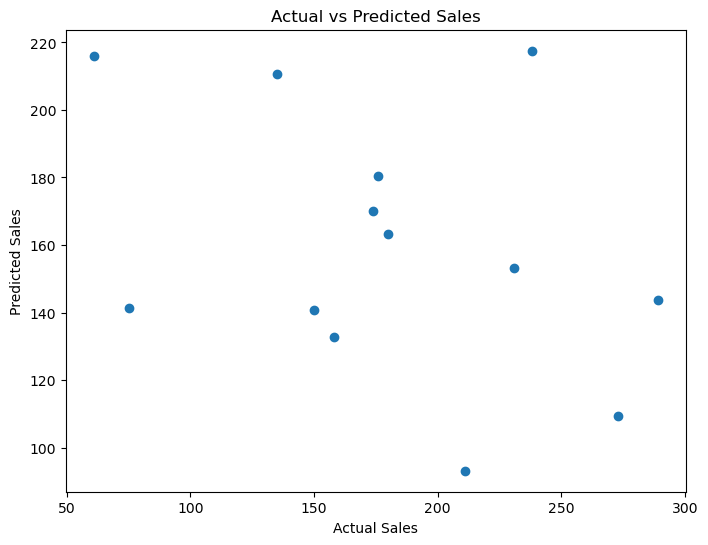